# The Ten Best Days — a quantitative teardown \U0001F52C
### The omitted symmetric statistic · a shuffle test for clustering · the break-even hit rate

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The load-bearing
measurement is the shuffle test in §3.2: it preserves every return and destroys only the order,
which separates *fat tails* from *clustering* and shows the brochure's counterfactual to be
structurally unavailable rather than merely improbable.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from bestdays import data, strategy as st

px = data.load_prices()
r = px[data.EQUITY].dropna().pct_change().dropna()
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions from "
      f"{r.index[0].date()} ({len(r)/252:.1f} years)")
print(f"buy and hold: {st.annualised(r):.2%} a year")

as-of 2026-06-30 | SPY: 8,410 sessions from 1993-02-01 (33.4 years)
buy and hold: 10.83% a year


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | The arithmetic is correct. On SPY over 33 years, missing the ten best sessions cuts the annualised return from 10.83% to 8.10% — a loss of **2.74% a year** from ten days out of 8,410. The brochure stops there. Missing the ten **worst** sessions raises it to 13.78%, a gain of **2.94% a year** — **1.07× the size of the loss**. The reason is not the one you would guess. In percentage terms the ten best days are the *bigger* ones (+8.74% against -8.36%), so "crashes are larger than rallies" is simply false here. The asymmetry survives because compounding is multiplicative: removing a day multiplies the result by 1/(1+x), so the quantity that matters is log(1+x) — and in log terms the worst days are the larger (-0.0875 against +0.0835). And the two sets are not scattered through history: the median distance from a best day to the nearest worst day is **6 sessions**, against 290 when the same returns are shuffled (p = 0.000). They arrive in the same storms — the best days occurred at a median drawdown of -34.7% and in volatility 5.8× normal. Being absent for all ten best days while present for all ten worst is not an outcome any rule can produce. |
| **Tradability** | Fragile | Which makes the interesting question the one nobody asks: how accurate would a timer need to be? Take a rule that sits out 20% of all sessions — 1,682 days — and score it on the share of those days that turn out to be down days. **Choosing at random already achieves 45.2%**, the unconditional down-day frequency, so that and not 50% is the benchmark. Break-even against buy-and-hold arrives at **47.7%**, an edge of only **2.5 percentage points** over random. That sounds modest, and the modesty is the trap: the frontier is savagely steep on both sides. Random selection — sitting out 20% of days with no skill whatsoever — returns 8.59% against buy-and-hold's 10.83%, and a timer 5 points *below* random gets 4.40%. The edge must be small, positive, and sustained across every one of 1,682 decisions; being slightly wrong is far more expensive than being slightly right is profitable. For scale, missing 84 days chosen at random costs 0.12% a year while missing the 84 *best* costs 11.93% — the brochure quotes the worst case of a selection no process generates. |

> \U0001F4A1 **In plain words.** True statistic, false inference, and a better argument
> available.

## 1 · Hypotheses

- **H₁ (arithmetic).** Missing the ten best sessions materially reduces the annualised return.
- **H₂ (omitted half).** Missing the ten worst helps by *more* than missing the ten best hurts,
  in a majority of markets.
- **H₃ (clustering).** The median distance from a best day to the nearest worst day is far
  smaller than under a shuffle of the same returns.
- **H₄ (mechanism).** Volatility clustering, not the fat tail, is what produces H₃ — testable
  because the two can be varied independently in synthetic data.
- **H₅ (the honest question).** The hit rate a switching rule needs to break even is far above a
  coin flip.

## 2 · Data and construction

In [3]:
rows = []
for tk in data.TICKERS:
    if tk not in px.columns:
        continue
    s = px[tk].dropna().pct_change().dropna()
    rows.append({"asset": tk, "n": len(s), "from": s.index[0].date(),
                 "cagr": st.annualised(s), "vol": s.std() * np.sqrt(252),
                 "skew": s.skew(), "excess kurtosis": s.kurtosis()})
print(pd.DataFrame(rows).set_index("asset").round(4).to_string())

          n        from   cagr    vol    skew  excess kurtosis
asset                                                         
SPY    8410  1993-02-01 0.1083 0.1858 -0.0116          11.8226
QQQ    6868  1999-03-11 0.1098 0.2695  0.2251           7.1332
IWM    6560  2000-05-30 0.0891 0.2390 -0.2583           5.3441
EFA    6245  2001-08-28 0.0649 0.2080 -0.0274          13.0525
EEM    5839  2003-04-15 0.1020 0.2712  0.4756          17.9660
TLT    6017  2002-07-31 0.0374 0.1430  0.0539           3.4890
BIL    4801  2007-05-31 0.0136 0.0049 -0.1408          49.6763


## 3 · The teardown

### 3.1 Both halves of the statistic, every market

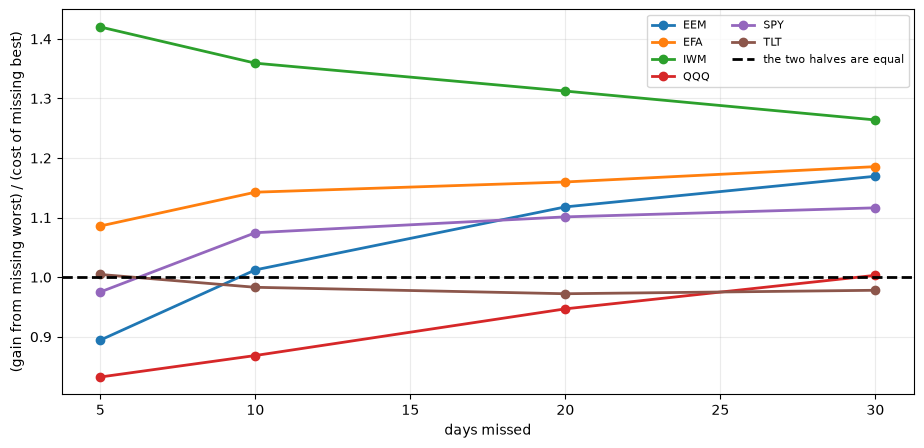

asset     EEM    EFA    IWM    QQQ    SPY    TLT
n_days                                          
5      0.8940 1.0860 1.4200 0.8330 0.9750 1.0050
10     1.0120 1.1430 1.3590 0.8690 1.0750 0.9830
20     1.1180 1.1600 1.3120 0.9470 1.1010 0.9720
30     1.1690 1.1860 1.2640 1.0030 1.1160 0.9780


In [4]:
rows = []
for tk in data.TICKERS:
    if tk == data.CASH or tk not in px.columns:
        continue
    s = px[tk].dropna().pct_change().dropna()
    if len(s) < 1500:
        continue
    for n in (5, 10, 20, 30):
        a = st.asymmetry(s, n)
        rows.append({"asset": tk, "n_days": n, "cost_best": a["cost_of_missing_best"],
                     "gain_worst": a["benefit_of_missing_worst"], "ratio": a["ratio"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5))
piv = d.pivot(index="n_days", columns="asset", values="ratio")
piv.plot(ax=ax, marker="o", lw=2)
ax.axhline(1.0, color="k", ls="--", lw=2, label="the two halves are equal")
ax.set_xlabel("days missed")
ax.set_ylabel("(gain from missing worst) / (cost of missing best)")
ax.legend(fontsize=8, ncol=2)
plt.show()
print(piv.round(3).to_string())

> \U0001F4A1 **In plain words.** Every line above 1.0 is a market where the unquoted half of the
> statistic is the bigger half.

### 3.2 The shuffle test — the load-bearing measurement

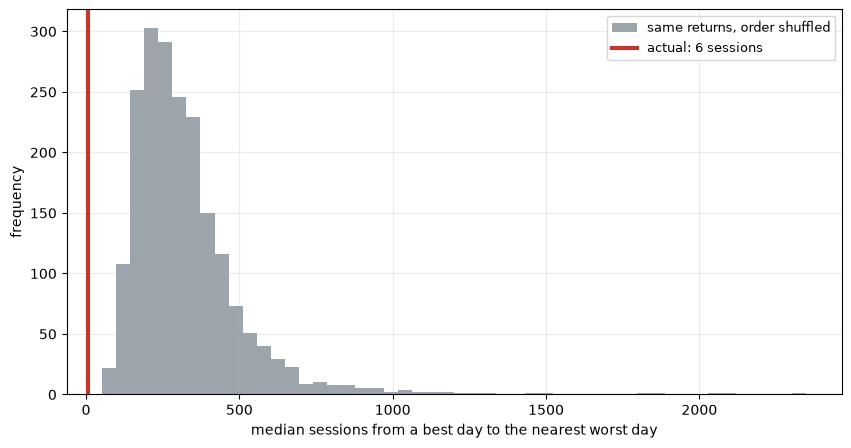

actual 6, shuffled median 285, p = 0.0000
The shuffle keeps every return. Only the ORDER changes.


In [5]:
r_np = r.to_numpy()
n_ex = 10
def gap_of(x):
    o = np.argsort(x); b = np.sort(o[-n_ex:]); w = np.sort(o[:n_ex])
    return float(np.median(np.abs(b[:, None] - w[None, :]).min(axis=1)))
rng = np.random.default_rng(1002)
null = np.array([gap_of(rng.permutation(r_np)) for _ in range(2000)])
actual = gap_of(r_np)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null, bins=50, color="#8b949e", alpha=0.85,
        label="same returns, order shuffled")
ax.axvline(actual, color="#c0392b", lw=3, label=f"actual: {actual:.0f} sessions")
ax.set_xlabel("median sessions from a best day to the nearest worst day")
ax.set_ylabel("frequency"); ax.legend(fontsize=9)
plt.show()
print(f"actual {actual:.0f}, shuffled median {np.median(null):.0f}, "
      f"p = {(null <= actual).mean():.4f}")
print("The shuffle keeps every return. Only the ORDER changes.")

### 3.3 The mechanism, isolated

                gap  ratio  kurtosis
clustering                          
off        356.3750 1.2750    2.3840
on          93.7500 0.3310   28.7730


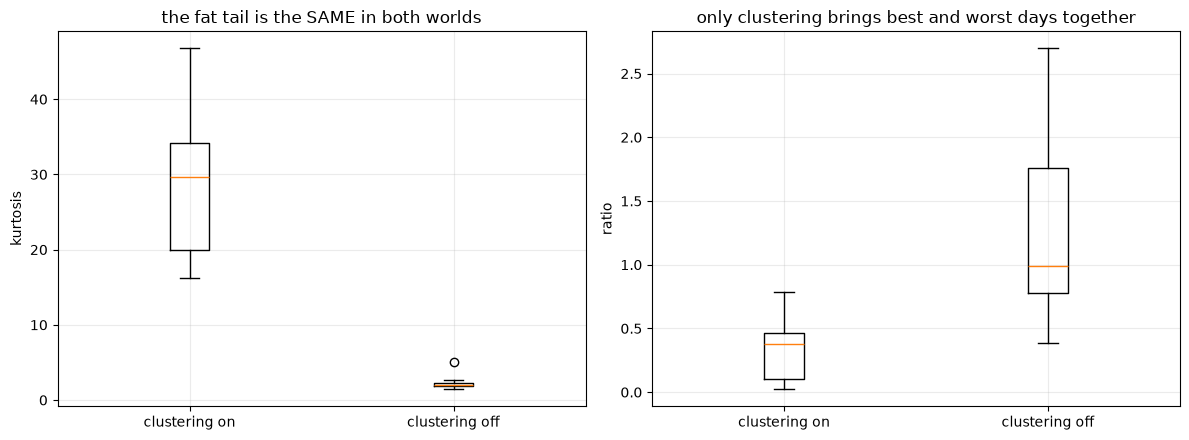

In [6]:
rows = []
for clustered in (True, False):
    for k in range(8):
        sim = st.synthetic_returns(n=8000, clustered=clustered, seed=1002 + k)
        c = st.clustering_stats(sim, 10, 200, seed=1002 + k)
        rows.append({"clustering": "on" if clustered else "off",
                     "gap": c["median_gap"], "ratio": c["ratio"],
                     "kurtosis": sim.kurtosis()})
d = pd.DataFrame(rows)
print(d.groupby("clustering")[["gap", "ratio", "kurtosis"]].mean().round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, col in enumerate(["kurtosis", "ratio"]):
    axes[i].boxplot([d[d["clustering"] == c][col] for c in ("on", "off")],
                    tick_labels=["clustering on", "clustering off"])
    axes[i].set_ylabel(col)
axes[0].set_title("the fat tail is the SAME in both worlds")
axes[1].set_title("only clustering brings best and worst days together")
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** Fat tails alone do not put the best days next to the worst
> days. Volatility clustering does. This is why the effect is a fact about crashes, not a fact
> about the return distribution.

### 3.4 Volatility and drawdown context

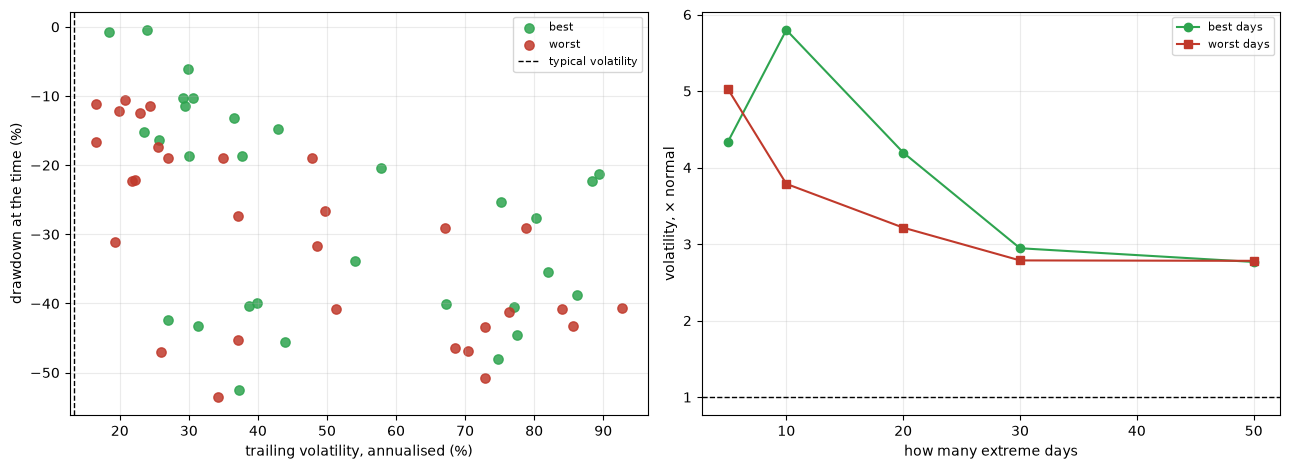

    best_median_drawdown  worst_median_drawdown  typical_drawdown
10               -0.3469                -0.2821           -0.0378
20               -0.2650                -0.3013           -0.0378
30               -0.2381                -0.2909           -0.0378


In [7]:
ex = st.extreme_days(r, 30)
vol = r.rolling(21).std().shift(1) * np.sqrt(252)
eq = (1 + r).cumprod(); dd = eq / eq.cummax() - 1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for kind, col in (("best", "#2ea44f"), ("worst", "#c0392b")):
    dts = ex[ex["kind"] == kind]["date"]
    axes[0].scatter(vol.reindex(dts) * 100, dd.reindex(dts) * 100, s=45, color=col,
                    label=kind, alpha=0.85)
axes[0].axvline(vol.median() * 100, color="k", ls="--", lw=1, label="typical volatility")
axes[0].set_xlabel("trailing volatility, annualised (%)")
axes[0].set_ylabel("drawdown at the time (%)"); axes[0].legend(fontsize=8)
ctx = pd.DataFrame([st.volatility_context(r, n) for n in (5, 10, 20, 30, 50)],
                   index=[5, 10, 20, 30, 50])
axes[1].plot(ctx.index, ctx["best_vol_ratio"], "o-", color="#2ea44f", label="best days")
axes[1].plot(ctx.index, ctx["worst_vol_ratio"], "s-", color="#c0392b", label="worst days")
axes[1].axhline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("how many extreme days")
axes[1].set_ylabel("volatility, × normal"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(pd.DataFrame([st.drawdown_context(r, n) for n in (10, 20, 30)],
                   index=[10, 20, 30]).round(4).to_string())

### 3.5 The random-days null

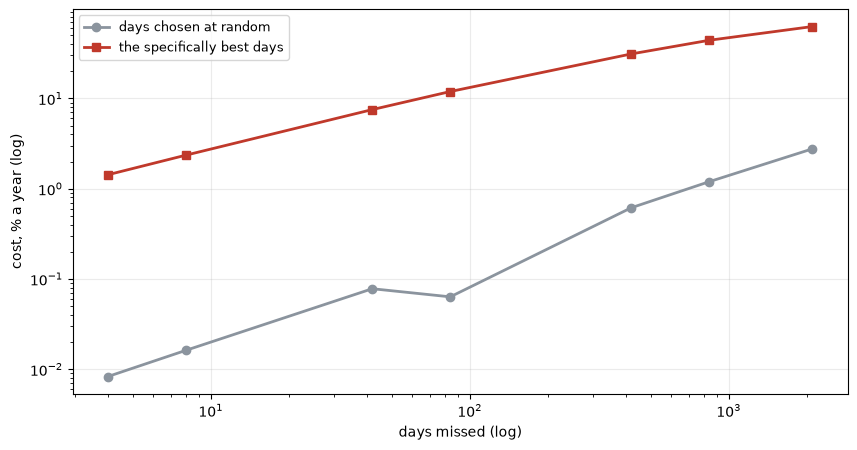

,days,random_median_cagr,random_p05,worst_case_cagr,buy_and_hold,random_cost,worst_case_cost,ratio
fraction,,,,,,,,
0.0005,4,0.1083,0.1071,0.0941,0.1083,0.0001,0.0143,172.0887
0.0010,8,0.1082,0.1066,0.0848,0.1083,0.0002,0.0235,145.4291
0.0050,42,0.1076,0.1036,0.0330,0.1083,0.0008,0.0753,96.5732
0.0100,84,0.1077,0.1017,-0.0110,0.1083,0.0006,0.1193,188.2340
0.0500,420,0.1022,0.0902,-0.2031,0.1083,0.0062,0.3115,50.6019
0.1000,841,0.0964,0.0793,-0.3333,0.1083,0.0120,0.4417,36.8697
0.2500,2102,0.0807,0.0548,-0.5181,0.1083,0.0276,0.6264,22.6583


In [8]:
oc = st.out_of_market_cost(r, fractions=(0.0005, 0.001, 0.005, 0.01, 0.05, 0.10,
                                          0.25), n_draws=400)
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(oc["days"], oc["random_cost"] * 100, "o-", lw=2, color="#8b949e",
          label="days chosen at random")
ax.loglog(oc["days"], oc["worst_case_cost"] * 100, "s-", lw=2, color="#c0392b",
          label="the specifically best days")
ax.set_xlabel("days missed (log)"); ax.set_ylabel("cost, % a year (log)")
ax.legend(fontsize=9)
plt.show()
oc.assign(ratio=oc["worst_case_cost"] / oc["random_cost"]).round(4)

### 3.6 The break-even frontier, and how it moves

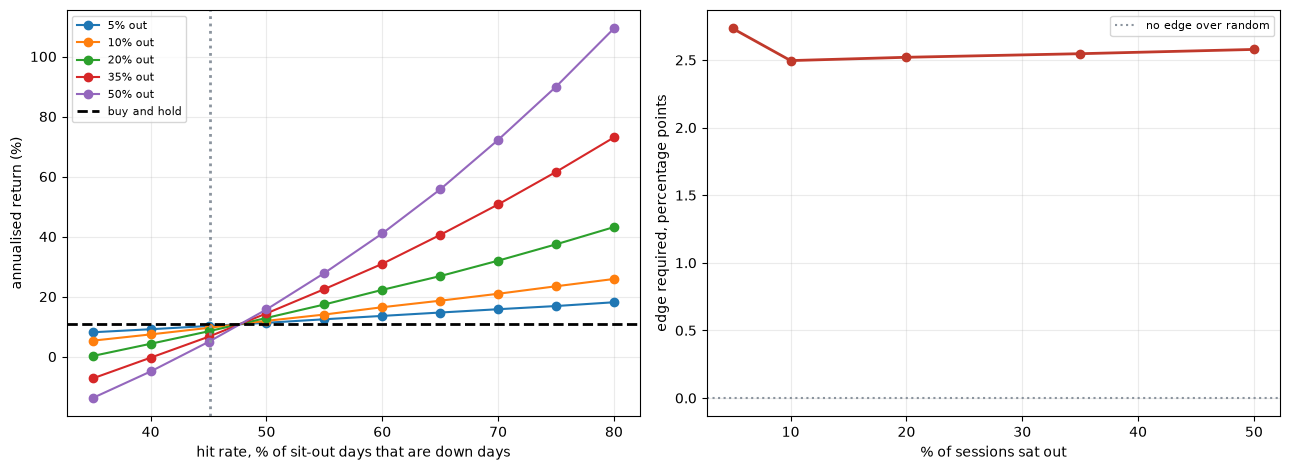

out
0.0500   0.0273
0.1000   0.0250
0.2000   0.0252
0.3500   0.0255
0.5000   0.0258


In [9]:
rate = st.down_day_share(r)
rows = []
for frac in (0.05, 0.10, 0.20, 0.35, 0.50):
    f = st.timing_frontier(r, frac, np.arange(0.35, 0.81, 0.05), n_draws=200)
    be = st.breakeven_hit_rate(r, frac)
    for hr, row in f.iterrows():
        rows.append({"out": frac, "hit_rate": hr, "cagr": row["median_cagr"],
                     "breakeven": be})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for fr, g in d.groupby("out"):
    axes[0].plot(g["hit_rate"] * 100, g["cagr"] * 100, "o-", label=f"{fr:.0%} out")
axes[0].axhline(st.annualised(r) * 100, color="k", ls="--", lw=2, label="buy and hold")
axes[0].axvline(rate * 100, color="#8b949e", ls=":", lw=2)
axes[0].set_xlabel("hit rate, % of sit-out days that are down days")
axes[0].set_ylabel("annualised return (%)"); axes[0].legend(fontsize=8)
be = d.groupby("out")["breakeven"].first()
axes[1].plot(be.index * 100, (be - rate) * 100, "o-", lw=2, color="#c0392b")
axes[1].axhline(0, color="#8b949e", ls=":", lw=1.5, label="no edge over random")
axes[1].set_xlabel("% of sessions sat out")
axes[1].set_ylabel("edge required, percentage points")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print((be - rate).round(4).to_string())

> \U0001F4A1 **In plain words.** The more a timer trades, the more accurate it has to be. That is
> the real headwind, and it is a statement about the timer rather than about ten particular
> days.

### 3.7 Does the whole thing rest on 2008?

In [10]:
rows = []
for lo, hi in [(1993, 2007), (2003, 2013), (2010, 2020), (2015, 2026), (1993, 2026)]:
    s = r[(r.index.year >= lo) & (r.index.year <= hi)]
    if len(s) < 750:
        continue
    a = st.asymmetry(s, 10)
    c = st.clustering_stats(s, 10, 200)
    rows.append({"window": f"{lo}-{hi}", "n": len(s), "cagr": a["base_cagr"],
                 "cost_best": a["cost_of_missing_best"],
                 "gain_worst": a["benefit_of_missing_worst"], "ratio": a["ratio"],
                 "gap": c["median_gap"], "shuffled_gap": c["shuffled_median_gap"],
                 "p": c["p_value"]})
d = pd.DataFrame(rows).set_index("window")
print(d.round(4).to_string())

              n   cagr  cost_best  gain_worst  ratio     gap  shuffled_gap      p
window                                                                           
1993-2007  3758 0.1031     0.0370      0.0385 1.0402 23.0000      129.0000 0.0000
2003-2013  2769 0.0910     0.0676      0.0748 1.1055  3.0000       93.5000 0.0000
2010-2020  2769 0.1389     0.0581      0.0712 1.2257  3.0000       96.0000 0.0000
2015-2026  2889 0.1379     0.0617      0.0676 1.0971  3.0000       99.2500 0.0000
1993-2026  8410 0.1083     0.0274      0.0294 1.0746  5.5000      286.2500 0.0000


> \U0001F4A1 **In plain words.** The asymmetry ratio moves around with the sample — it is the
> weaker of the two findings and depends on whether a crash is in the window. The clustering
> result holds in every sub-period, which is why the verdict leans on it.

## 4 · The verdict

In [11]:
a = st.asymmetry(r, 10)
c = st.clustering_stats(r, 10, 400)
dc = st.drawdown_context(r, 10)
vc = st.volatility_context(r, 10)
oc1 = st.out_of_market_cost(r, fractions=(0.01,), n_draws=300).iloc[0]
pd.DataFrame({
    "buy and hold, % a year": [a["base_cagr"]],
    "cost of missing the 10 best": [a["cost_of_missing_best"]],
    "gain from missing the 10 worst": [a["benefit_of_missing_worst"]],
    "ratio (omitted / quoted)": [a["ratio"]],
    "median best-to-worst gap, sessions": [c["median_gap"]],
    "the same, shuffled": [c["shuffled_median_gap"]],
    "clustering p-value": [c["p_value"]],
    "median drawdown on a best day": [dc["best_median_drawdown"]],
    "volatility on a best day, x normal": [vc["best_vol_ratio"]],
    "cost of missing 1% of days at random": [oc1["random_cost"]],
    "cost of missing the best 1% of days": [oc1["worst_case_cost"]],
    "10 best days, mean % return": [a["mean_best"]],
    "10 worst days, mean % return": [a["mean_worst"]],
    "10 best days, mean log return": [a["log_best"]],
    "10 worst days, mean log return": [a["log_worst"]],
    "random timer's hit rate": [st.down_day_share(r)],
    "break-even hit rate for a timer": [st.breakeven_hit_rate(r, 0.20)],
    "edge required over random": [st.breakeven_hit_rate(r, 0.20)
                                  - st.down_day_share(r)],
}).T.rename(columns={0: "value"}).round(4)

,value
"buy and hold, % a year",0.1083
cost of missing the 10 best,0.0274
gain from missing the 10 worst,0.0294
ratio (omitted / quoted),1.0746
"median best-to-worst gap, sessions",5.5000
"the same, shuffled",283.2500
clustering p-value,0.0000
median drawdown on a best day,-0.3469
"volatility on a best day, x normal",5.7983
cost of missing 1% of days at random,0.0010


## 5 · Going further

- **Estrada (2008)** runs the two-sided version across fifteen markets and over a century in
  places; this study adds the clustering test and the synthetic control that identifies its
  mechanism.
- **Sharpe (1975)** computed a break-even timing accuracy of roughly 74% under a different
  parameterisation. Reconciling his monthly bull/bear formulation with the daily sit-out
  formulation here would make a clean short note.
- **Condition on the rule.** The frontier here treats hit rate as a free parameter. Mapping an
  actual rule — a moving-average cross, a volatility target — onto its realised hit rate would
  turn the frontier into a verdict on that rule, which is what **211-market-timing** does from
  the other direction.
- **Add costs and taxes.** Both raise the break-even, and a realistic version would report the
  after-tax threshold for a taxable account, which is materially higher again.